In [1]:
library(devtools)
source_url("https://raw.githubusercontent.com/aygoldberg/PIC-seq/master/scripts/metacell_functions.r")
source_url("https://raw.githubusercontent.com/aygoldberg/PIC-seq/master/scripts/pic_parser.r")
library(GEOquery)
library(googlesheets4)
library(googledrive)
library(ggplot2)
library(ggrepel)
library(dplyr)
library(gridExtra)
library(tidyverse)
library(grid)
library(SingleCellExperiment)
library(ComplexHeatmap)
library(GOfuncR)
library(cowplot)
library(shades)
library(circlize)
library(babelgene)
library(zellkonverter)
library(R.utils)
library(rstatix) 
library(RVAideMemoire)
library(cluster)   
library(factoextra) 
library(ggpmisc)
library(glmGamPoi)
library(MASS)
library(clusterProfiler)

Loading required package: usethis

ℹ SHA-1 hash of file is "bda7f06ee7b168c0be4c723ee15644ab99e6421e"
Loading required package: KernSmooth

KernSmooth 2.23 loaded
Copyright M. P. Wand 1997-2009

Loading required package: reshape2

Loading required package: RANN

Loading required package: plyr

Loading required package: plotrix

Loading required package: gplots


---------------------
gplots 3.3.0 loaded:
  * Use citation('gplots') for citation info.
  * Homepage: https://talgalili.github.io/gplots/
  * Report issues: https://github.com/talgalili/gplots/issues
  * Ask questions: https://stackoverflow.com/questions/tagged/gplots
  * Suppress this message with: suppressPackageStartupMessages(library(gplots))
---------------------



Attaching package: ‘gplots’


The following object is masked from ‘package:plotrix’:

    plotCI


The following object is masked from ‘package:stats’:

    lowess


Loading required package: parallel

Loading required package: compositions

Welcome to composi

In [ ]:
library(dplyr)
library(tidyverse)
library(rstatix)
library(reshape2)
library(MASS)
library(scales)
library(flowWorkspace)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


The following object is masked from ‘package:plotrix’:

    rescale


As part of improvements to flowWorkspace, some behavior of
GatingSet objects has changed. For details, please read the section
titled "The cytoframe and cytoset classes" in the package vignette:

  vignette("flowWorkspace-Introduction", "flowWorkspace")


Attaching package: ‘flowWorkspace’


The following object is masked from ‘package:R.utils’:

    getParent




In [ ]:
phago_color_scale = c('#D3D3D3', '#FF97E2', '#8A54A5')

In [ ]:
facs_data = read_csv('projects/phago/B16/tables/export_Specimen_001_PBS1_not-.csv') %>% as.data.frame

Rows: 6894 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (11): FSC-A, SSC-A, Comp-B 530_30 - 505LP-A :: CLEC4D, Comp-B 710_50 - 6...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
facs_data$rank_color = rank(facs_data$`Comp-YG 586_15 - 570LP-A :: pHrodo`)

[1] "p = 3.42e-05, R = -0.0746"


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


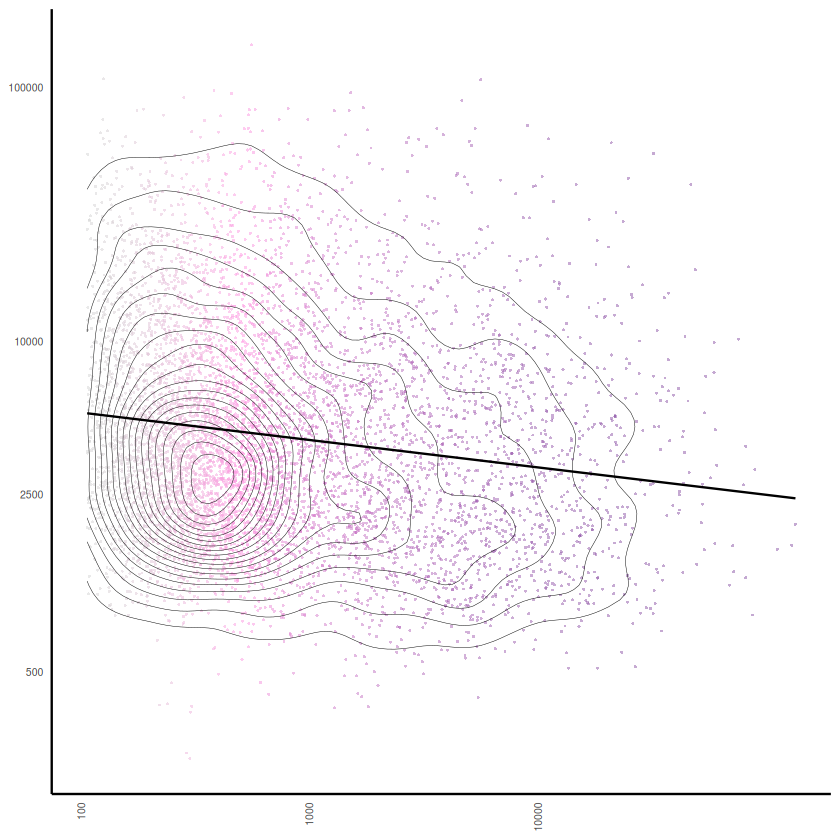

In [ ]:
# Fit linear model
model <- lm(`Comp-V 525_50 - 505LP-A :: MHC-II` ~ `Comp-YG 586_15 - 570LP-A :: pHrodo`, data = facs_data)
r_val <- coef(model)[2]
p_val <- summary(model)$coefficients[2, 4]  # Get p-value for the slope

# Format p-value for display
p_label <- paste0("p = ", signif(p_val, 3), ", R = ", signif(r_val, 3))
print(p_label)

ggplot(facs_data, aes(
    x = `Comp-YG 586_15 - 570LP-A :: pHrodo`,
    y = `Comp-V 525_50 - 505LP-A :: MHC-II`,
    color = rank_color
)) +
    geom_point(alpha = 0.5, size = 0.25, shape=16, show.legend = F) +
    stat_density_2d(color = "black", size = 0.5, bins = 20, linewidth=0.1) +  # Contour lines only
    scale_color_gradientn(colors = c('#D3D3D3', '#FF97E2', '#8A54A5')) +
    geom_smooth(method = "lm", color = "black", se = FALSE, size = 0.5) +
    labs(title = p_label) +
    scale_x_continuous(trans = scales::pseudo_log_trans(base = 10, sigma=10), breaks = c(100, 1000, 10000), labels = c("100", "1000", "10000")) +
    scale_y_continuous(trans = scales::pseudo_log_trans(base = 10, sigma=10), breaks = c(500, 2500, 10000, 100000), labels=c("500", "2500", "10000", "100000")) +
    theme_minimal() + 
    theme(plot.title = element_blank(), axis.line = element_line(color = "black"), 
          panel.border = element_blank(), panel.grid = element_blank(), axis.title.x = element_blank(), axis.title.y=element_blank(),
          axis.text.x = element_text(size=6, angle=90, hjust=1), axis.text.y = element_text(size=6))
ggsave('projects/phago/B16/plots/rodo_corr_MHCII.pdf', width = 40, height = 40, units = 'mm')

[1] "p = 2.6e-108, R = 0.0542"


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


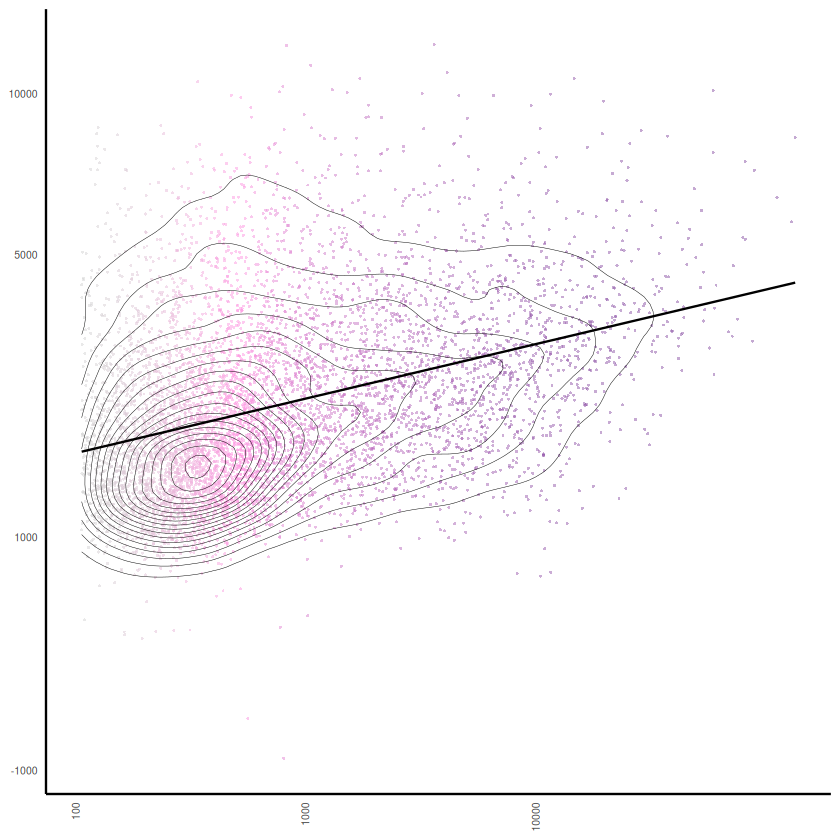

In [ ]:
# Fit linear model
model <- lm(`Comp-B 710_50 - 685LP-A :: PD-L1` ~ `Comp-YG 586_15 - 570LP-A :: pHrodo`, data = facs_data)
r_val <- coef(model)[2]
p_val <- summary(model)$coefficients[2, 4]  # Get p-value for the slope

# Format p-value for display
p_label <- paste0("p = ", signif(p_val, 3), ", R = ", signif(r_val, 3))
print(p_label)

ggplot(facs_data, aes(
    x = `Comp-YG 586_15 - 570LP-A :: pHrodo`,
    y = `Comp-B 710_50 - 685LP-A :: PD-L1`,
    color = rank_color
)) +
    geom_point(alpha = 0.5, size = 0.25, shape=16, show.legend = F) +
    stat_density_2d(color = "black", size = 0.5, bins = 20, linewidth=0.1) +  # Contour lines only
    scale_color_gradientn(colors = c('#D3D3D3', '#FF97E2', '#8A54A5')) +
    geom_smooth(method = "lm", color = "black", se = FALSE, size = 0.5) +
    labs(title = p_label) +
    scale_x_continuous(trans = scales::pseudo_log_trans(base = 10, sigma=10), breaks = c(100, 1000, 10000), labels = c("100", "1000", "10000")) +
    scale_y_continuous(trans = scales::pseudo_log_trans(base = 10, sigma=1000), breaks = c(-1000, 1000, 5000, 10000, 100000)) +
    theme_minimal() + 
    theme(plot.title = element_blank(), axis.line = element_line(color = "black"), 
          panel.border = element_blank(), panel.grid = element_blank(), axis.title.x = element_blank(), axis.title.y=element_blank(),
          axis.text.x = element_text(size=6, angle=90, hjust=1), axis.text.y = element_text(size=6))
ggsave('projects/phago/B16/plots/rodo_corr_PDL1.pdf', width = 40, height = 40, units = 'mm')

[1] "p = 3.39e-80, R = 0.225"


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


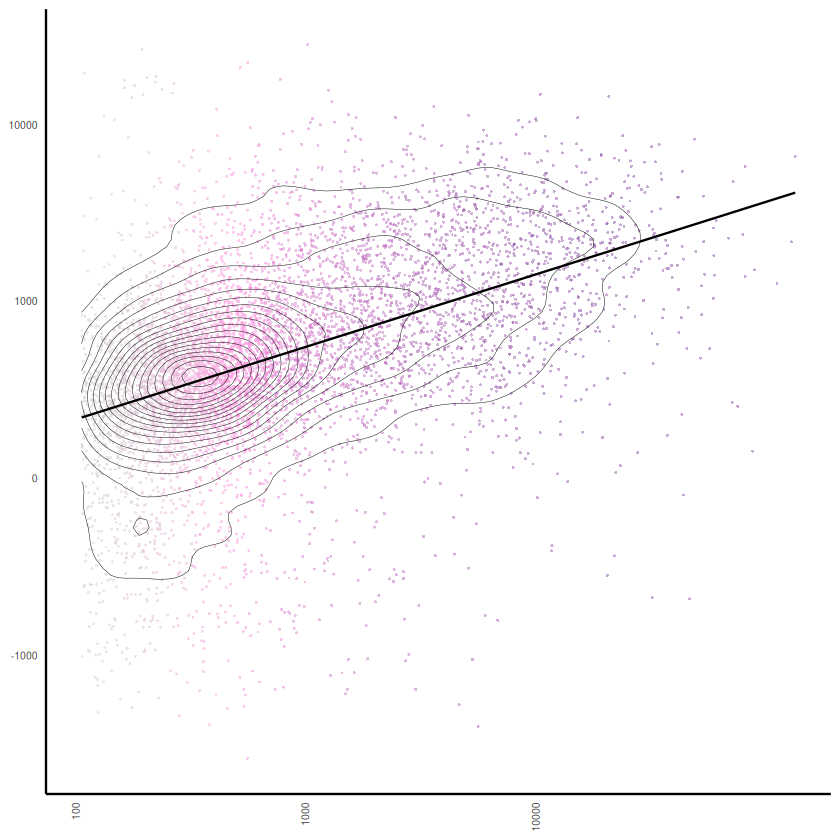

In [ ]:
# Fit linear model
model <- lm(`Comp-R 780_60 - 750LP-A :: PDPN` ~ `Comp-YG 586_15 - 570LP-A :: pHrodo`, data = facs_data)
r_val <- cor(facs_data$`Comp-YG 586_15 - 570LP-A :: pHrodo`, facs_data$`Comp-R 780_60 - 750LP-A :: PDPN`, method = "pearson", use = "complete.obs")
p_val <- summary(model)$coefficients[2, 4]  # Get p-value for the slope

# Format p-value for display
p_label <- paste0("p = ", signif(p_val, 3), ", R = ", signif(r_val, 3))
print(p_label)

ggplot(facs_data, aes(
    x = `Comp-YG 586_15 - 570LP-A :: pHrodo`,
    y = `Comp-R 780_60 - 750LP-A :: PDPN`,
    color = rank_color
)) +
    geom_point(alpha = 0.5, size = 0.25, shape=16, show.legend = F) +
    stat_density_2d(color = "black", size = 0.5, bins = 20, linewidth=0.1) +  # Contour lines only
    scale_color_gradientn(colors = c('#D3D3D3', '#FF97E2', '#8A54A5')) +
    geom_smooth(method = "lm", color = "black", se = FALSE, size = 0.5) +
    labs(title = p_label) +
    scale_x_continuous(trans = scales::pseudo_log_trans(base = 10, sigma=10), breaks = c(100, 1000, 10000), labels = c("100", "1000", "10000")) +
    scale_y_continuous(trans = scales::pseudo_log_trans(base = 10, sigma=100), breaks = c(-1000, 0, 1000, 10000, 100000)) +
    theme_minimal() + 
    theme(plot.title = element_blank(), axis.line = element_line(color = "black"), 
          panel.border = element_blank(), panel.grid = element_blank(), axis.title.x = element_blank(), axis.title.y=element_blank(),
          axis.text.x = element_text(size=6, angle=90, hjust=1), axis.text.y = element_text(size=6))
ggsave('projects/phago/B16/plots/rodo_corr_PDPN.pdf', width = 40, height = 40, units = 'mm')